In [22]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
orders = pd.read_csv('D:/ecommerce-analysis/data/olist_orders_dataset.csv')
items = pd.read_csv('D:/ecommerce-analysis/data/olist_order_items_dataset.csv')

# Cek data
print("Orders shape:", orders.shape)
print("Items shape:", items.shape)
orders.head()

Orders shape: (99441, 8)
Items shape: (112650, 7)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [24]:
# Konversi kolom tanggal
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Ambil bulan & tahun
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Hitung jumlah order per bulan
monthly_orders = orders.groupby('month').size().reset_index(name='total_orders')

print(monthly_orders)

      month  total_orders
0   2016-09             4
1   2016-10           324
2   2016-12             1
3   2017-01           800
4   2017-02          1780
5   2017-03          2682
6   2017-04          2404
7   2017-05          3700
8   2017-06          3245
9   2017-07          4026
10  2017-08          4331
11  2017-09          4285
12  2017-10          4631
13  2017-11          7544
14  2017-12          5673
15  2018-01          7269
16  2018-02          6728
17  2018-03          7211
18  2018-04          6939
19  2018-05          6873
20  2018-06          6167
21  2018-07          6292
22  2018-08          6512
23  2018-09            16
24  2018-10             4


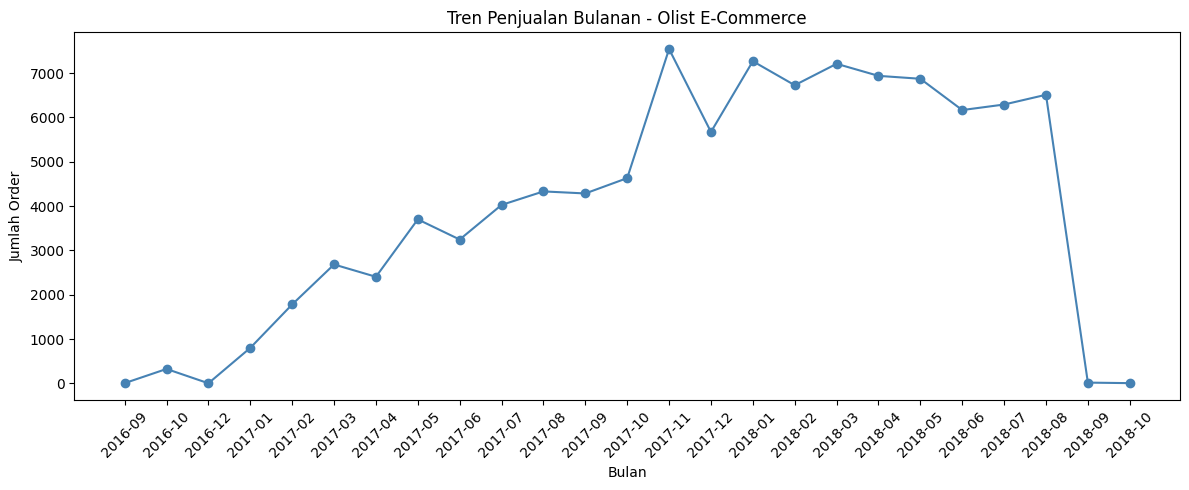

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders['month'].astype(str), monthly_orders['total_orders'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Tren Penjualan Bulanan - Olist E-Commerce')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.tight_layout()
plt.show()

In [28]:
# Gabungkan data orders & items
merged = pd.merge(orders, items, on='order_id')

# Hitung produk terlaris berdasarkan jumlah terjual
top_products = merged.groupby('product_id')['order_item_id'].count().sort_values(ascending=False).head(10)

print(top_products)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: order_item_id, dtype: int64


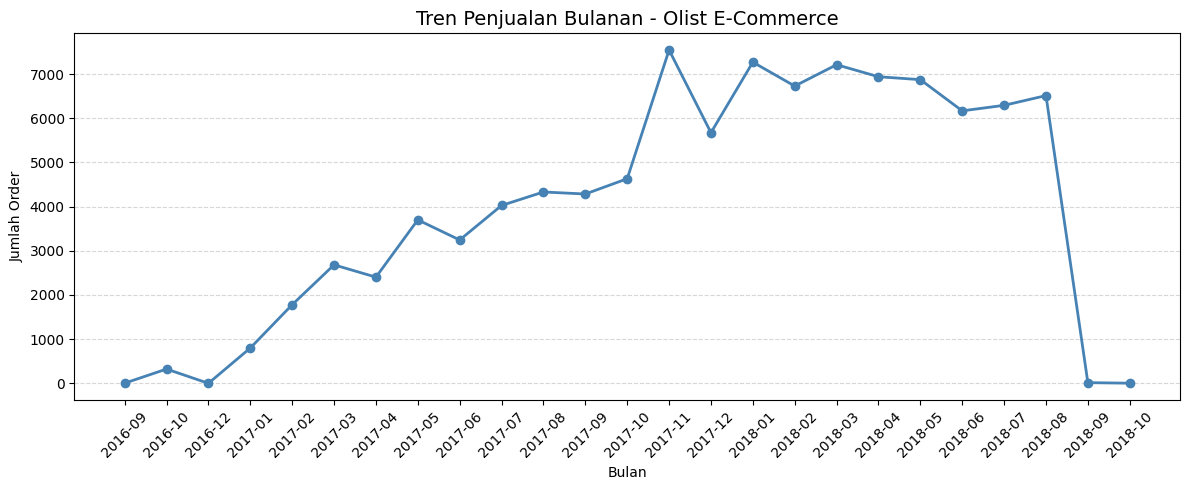

In [30]:
# Konversi kolom tanggal
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Hitung order per bulan
monthly_orders = orders.groupby('month').size().reset_index(name='total_orders')

# Grafik
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders['month'].astype(str), monthly_orders['total_orders'], 
         marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45)
plt.title('Tren Penjualan Bulanan - Olist E-Commerce', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

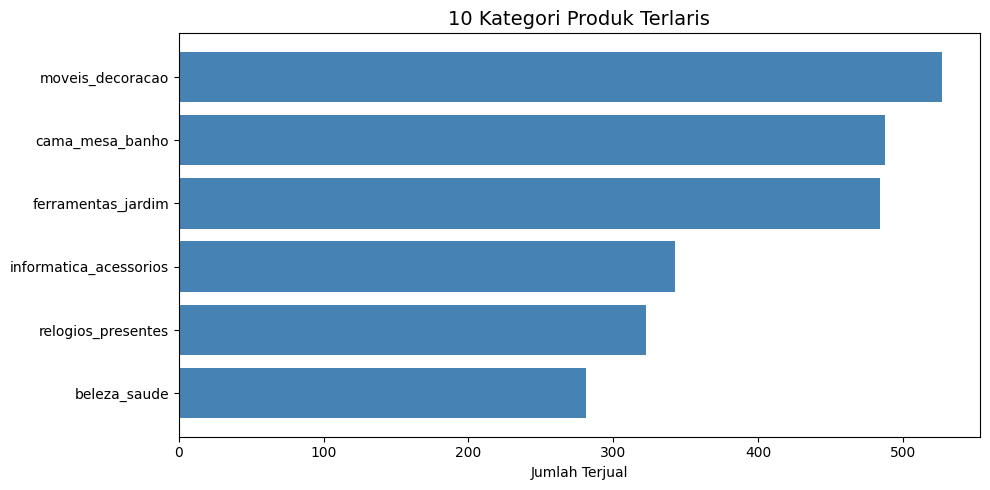

In [31]:
# Load data produk & kategori
products = pd.read_csv(r'D:\ecommerce-analysis\data\olist_products_dataset.csv')

# Gabungkan top_products dengan nama kategori
top10 = top_products.reset_index()
top10 = top10.merge(products[['product_id', 'product_category_name']], on='product_id')

# Grafik bar horizontal
plt.figure(figsize=(10, 5))
plt.barh(top10['product_category_name'], top10['order_item_id'], color='steelblue')
plt.title('10 Kategori Produk Terlaris', fontsize=14)
plt.xlabel('Jumlah Terjual')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Analisis Penjualan E-Commerce - Olist Brasil

## Tujuan

Menganalisis tren penjualan dan kategori produk terlaris dari dataset e-commerce Olist Brasil.

## Insight Utama

1. Penjualan tumbuh signifikan dari 2016 hingga puncaknya November 2017 (~7.500 order/bulan)
2. Kategori furniture & dekorasi rumah menjadi produk terlaris
3. Penjualan stabil di kisaran 6.000–7.000 order sepanjang 2018

## Tools

- Python, Pandas, Matplotlib
